# 02 · Imputation
### The Outliers · Mumbai Rent Radar

Cleaning left honest gaps behind. **10.8% of listings are missing at least one value.**
Throwing those rows away would waste real data, so instead we fill the gaps carefully —
and we *show* that filling them does not distort the picture.

**Rule we follow:** never invent the answer. We impute the **inputs** (size, bathroom,
floor, furnishing). We do **not** impute the **target** (rent) — a listing with no price
cannot teach a price model, so those few rows are set aside.

**Input:** `data/processed/listings_clean.csv` → **Output:** `data/processed/listings_imputed.csv`

In [2]:
import sys, warnings
sys.path.append("../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
import style
warnings.filterwarnings("ignore")
style.setup()

df = pd.read_csv("../data/processed/listings_clean.csv")
miss = df.isna().sum(); miss = miss[miss > 0].sort_values(ascending=False)
print("Missing values to resolve:\n", miss.to_string())

Missing values to resolve:
 size                 241
bathroom              88
locality_name         84
address               62
furnishing_status     53
rent                  50
total_floors          50
floor_num             29


## 1 · Why not just drop the gaps?
A quick count of what "drop every incomplete row" would actually cost us.

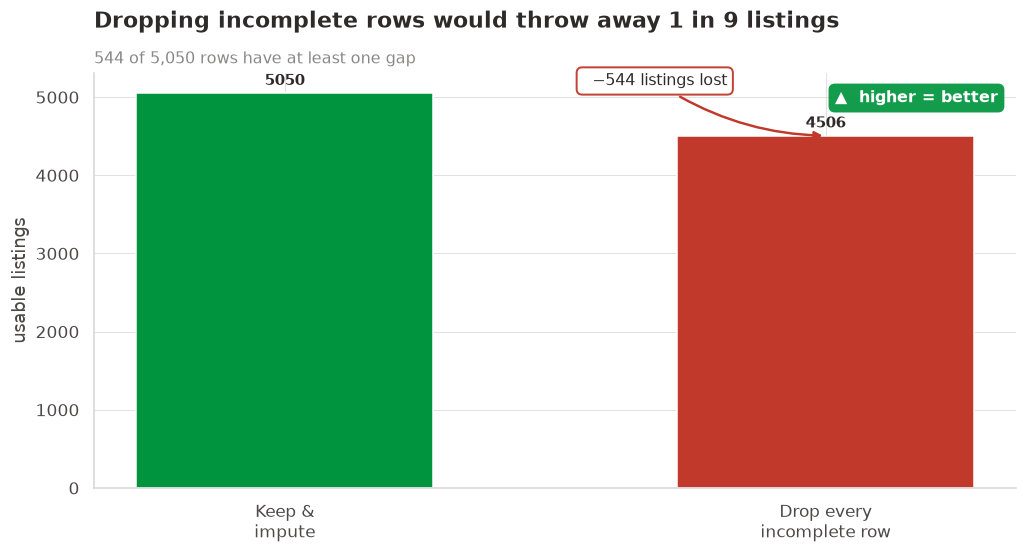

In [3]:
rows_any = (df.isna().sum(axis=1) > 0).sum()
fig, ax = plt.subplots(figsize=(9.5, 5.2))
bars = ax.bar(["Keep &\nimpute", "Drop every\nincomplete row"],
              [len(df), len(df) - rows_any],
              color=[style.GREEN, style.BAD], width=0.55)
style.bar_labels(ax, fmt="{:.0f}")
ax.set_ylabel("usable listings")
style.title(ax, "Dropping incomplete rows would throw away 1 in 9 listings",
            f"{rows_any:,} of {len(df):,} rows have at least one gap")
style.direction_badge(ax, "higher", "upper right")
style.callout(ax, (1, len(df) - rows_any), f"  −{rows_any:,} listings lost",
              xytext=(0.55, len(df) - rows_any + 700), color=style.BAD)
fig.tight_layout(); style.save(fig, "02_keep_vs_drop"); plt.show()

**Insight:** dropping is expensive and biased (incomplete listings are not random).
**Decision:** impute inputs; only rows with no rent at all are set aside.

## 2 · Size — choosing an imputation method by testing three
`Size` has the most gaps. Because size rises with **BHK** (correlation 0.73), a
BHK-aware fill should beat a blunt global median. We test three and compare the
**shape** of the result — a good imputation barely moves the distribution.

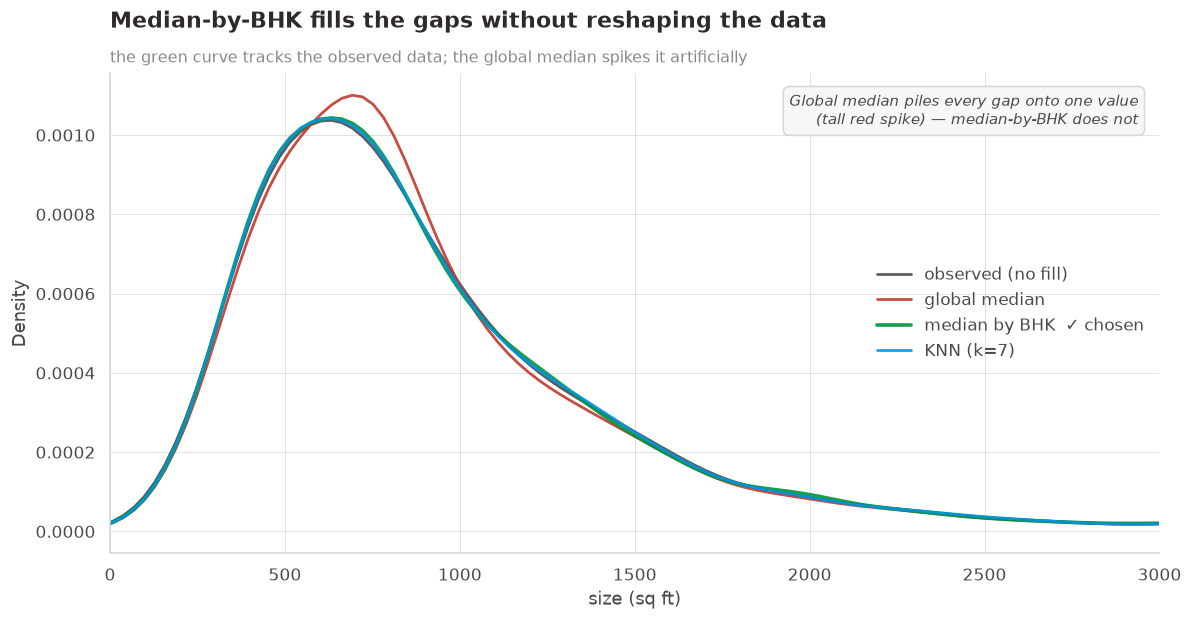

In [4]:
size_known = df["size"].dropna()
global_med = df["size"].fillna(df["size"].median())
bybhk = df["size"].fillna(df.groupby("bhk")["size"].transform("median"))
knn = df.copy()
knn_vals = KNNImputer(n_neighbors=7).fit_transform(knn[["size", "bhk", "bathroom", "floor_num"]])
knn_size = pd.Series(knn_vals[:, 0], index=df.index)

fig, ax = plt.subplots(figsize=(11, 5.8))
for series, lab, col in [(size_known, "observed (no fill)", style.CHARCOAL),
                         (global_med, "global median", style.BAD),
                         (bybhk, "median by BHK  ✓ chosen", style.GREEN),
                         (knn_size, "KNN (k=7)", style.BLUE)]:
    series.plot(kind="kde", ax=ax, label=lab, lw=2.4 if "chosen" in lab else 1.8,
                color=col, alpha=0.9)
ax.set_xlim(0, 3000); ax.set_xlabel("size (sq ft)")
style.title(ax, "Median-by-BHK fills the gaps without reshaping the data",
            "the green curve tracks the observed data; the global median spikes it artificially")
style.note(ax, "Global median piles every gap onto one value\n(tall red spike) — median-by-BHK does not",
           where="upper right")
ax.legend(title="", loc="center right")
fig.tight_layout(); style.save(fig, "02_size_methods"); plt.show()

In [5]:
comp = pd.DataFrame({
    "method": ["observed", "global median", "median by BHK", "KNN k=7"],
    "mean": [size_known.mean(), global_med.mean(), bybhk.mean(), knn_size.mean()],
    "std":  [size_known.std(),  global_med.std(),  bybhk.std(),  knn_size.std()],
}).round(0)
print(comp.to_string(index=False))
df["size"] = bybhk  # decision: median by BHK

       method  mean   std
     observed 944.0 698.0
global median 936.0 682.0
median by BHK 941.0 690.0
      KNN k=7 941.0 690.0


**Insight:** global median inflates the peak and shrinks the spread; median-by-BHK keeps
both mean and standard deviation closest to the observed data. KNN is similar but harder
to explain. **Decision:** fill `size` with the median size of its BHK class.

## 3 · Bathroom & floor — small, structural gaps
Bathrooms track BHK almost exactly (a 2BHK has ~2 baths), so we fill by BHK.
Floor number and building height get a simple median.

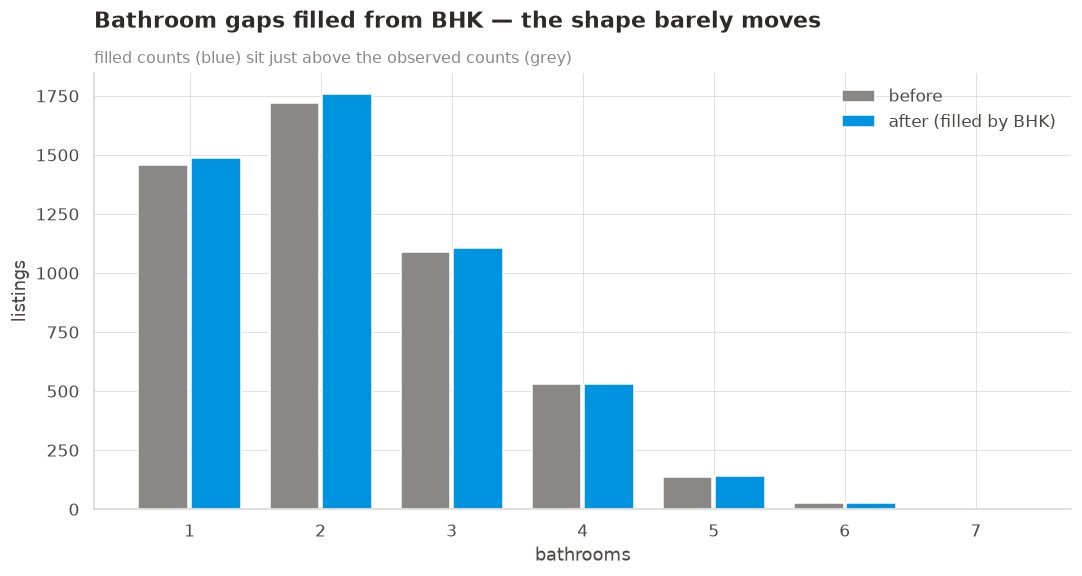

In [6]:
before_bath = df["bathroom"].copy()
df["bathroom"] = df["bathroom"].fillna(df.groupby("bhk")["bathroom"].transform("median")).round()
df["floor_num"] = df["floor_num"].fillna(df["floor_num"].median())
df["total_floors"] = df["total_floors"].fillna(df["total_floors"].median())

fig, ax = plt.subplots(figsize=(10, 5.4))
b_before = before_bath.value_counts().sort_index()
b_after = df["bathroom"].value_counts().sort_index()
idx = sorted(set(b_before.index) | set(b_after.index))
x = np.arange(len(idx))
ax.bar(x - 0.2, [b_before.get(i, 0) for i in idx], 0.38, label="before", color=style.GREY)
ax.bar(x + 0.2, [b_after.get(i, 0) for i in idx], 0.38, label="after (filled by BHK)", color=style.BLUE)
ax.set_xticks(x); ax.set_xticklabels([int(i) for i in idx]); ax.set_xlabel("bathrooms")
ax.set_ylabel("listings")
style.title(ax, "Bathroom gaps filled from BHK — the shape barely moves",
            "filled counts (blue) sit just above the observed counts (grey)")
ax.legend()
fig.tight_layout(); style.save(fig, "02_bathroom"); plt.show()

## 4 · Furnishing — a categorical gap
53 listings never stated furnishing. We fill with the most common status and confirm
the category mix hardly shifts.

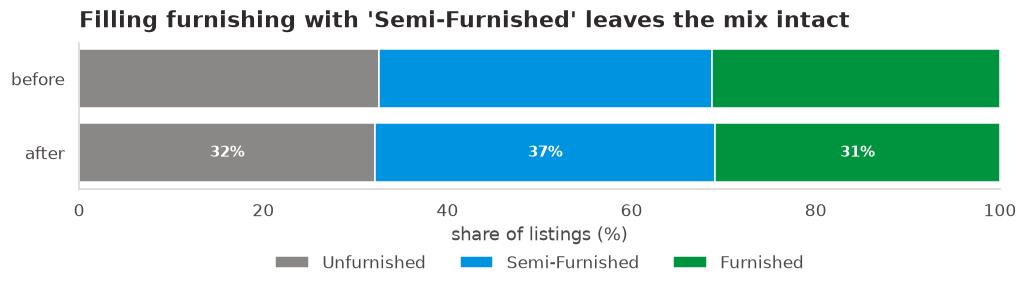

In [7]:
share_before = df["furnishing_status"].value_counts(normalize=True)
mode_furn = df["furnishing_status"].mode()[0]
df["furnishing_status"] = df["furnishing_status"].fillna(mode_furn)
share_after = df["furnishing_status"].value_counts(normalize=True)

order = ["Unfurnished", "Semi-Furnished", "Furnished"]
fig, ax = plt.subplots(figsize=(9.5, 3.2))
left_b = 0; left_a = 0
colors = {"Unfurnished": style.GREY, "Semi-Furnished": style.BLUE, "Furnished": style.GREEN}
for cat in order:
    ax.barh(1, share_before[cat] * 100, left=left_b, color=colors[cat], edgecolor="white")
    ax.barh(0, share_after[cat] * 100, left=left_a, color=colors[cat], edgecolor="white", label=cat)
    ax.text(left_a + share_after[cat] * 50, 0, f"{share_after[cat]*100:.0f}%", ha="center",
            va="center", color="white", fontweight="bold", fontsize=10)
    left_b += share_before[cat] * 100; left_a += share_after[cat] * 100
ax.set_yticks([0, 1]); ax.set_yticklabels(["after", "before"]); ax.set_xlim(0, 100)
ax.set_xlabel("share of listings (%)"); ax.grid(False)
style.title(ax, f"Filling furnishing with '{mode_furn}' leaves the mix intact")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.35))
fig.tight_layout(); style.save(fig, "02_furnishing"); plt.show()

**Insight:** the before/after split is visually identical — 53 rows out of 5,000 cannot
move the mix. **Decision:** mode-fill is safe here.

## 5 · Locality & the target
`locality_name` is an identity, not a number — it cannot be "averaged". The 84 rows with
no locality are tagged **Unknown** (they still have size/BHK/floor to model on). Rows with
**no rent** are set aside: we never manufacture the value we are trying to predict.

In [8]:
df["locality_name"] = df["locality_name"].fillna("Unknown")
n_before = len(df)
df = df[df["rent"].notna()].reset_index(drop=True)
print(f"Set aside {n_before - len(df)} rows with no rent (cannot train on a priceless listing).")
print("Remaining listings for analysis:", len(df))
print("Any missing left?\n", df.isna().sum()[df.isna().sum() > 0].to_string() or "none")

Set aside 50 rows with no rent (cannot train on a priceless listing).
Remaining listings for analysis: 5000
Any missing left?
 address    62


In [9]:
df.to_csv("../data/processed/listings_imputed.csv", index=False)
print("Saved listings_imputed.csv", df.shape)

Saved listings_imputed.csv (5000, 14)


## 6 · Imputation decisions, at a glance
| Field | Gap | Method | Why |
|---|---|---|---|
| `size` | 241 | median **by BHK** | size scales with BHK; keeps the distribution shape |
| `bathroom` | 88 | median **by BHK** | baths ≈ BHK almost exactly |
| `floor_num`,`total_floors` | 29 / 50 | median | small, structural gaps |
| `furnishing_status` | 53 | mode (`Semi-Furnished`) | too few to shift the mix |
| `locality_name` | 84 | tag **Unknown** | an identity cannot be averaged |
| `rent` (target) | 50 | **set aside** | never impute what you predict |

The data is now complete and honest. Next: describe what it actually looks like.